# Logistic Regression 

Used for binary classification

### When we use:
when the target is binary

- Spam / ham
- fraud / not fraud
- customer churn / no churn
- disease / no disease
- pass / fail
- purchase / no purchase


Logistic Regression predicts the probability of a class.


## Sigmoid function

This converts any real number into a value between 0 and 1.

In [3]:
import pandas as pd
from sklearn.datasets import make_classification

In [27]:
data = make_classification(n_samples=200,n_features=5,n_classes=2,random_state=42)

In [29]:
df = pd.DataFrame(data[0],columns=['f1','f2','f3','f4','f5'])

In [30]:
df['target'] = data[1]

In [31]:
df.head()

,f1,f2,f3,f4,f5,target
0,0.407719,-0.095667,1.502357,-1.209659,-1.277852,0
1,1.171938,-0.734462,0.311250,-0.052759,-2.182368,1
2,0.208795,0.045808,0.332314,-1.325960,-0.961946,0
3,-0.766396,0.297780,-0.351513,1.394775,2.019333,1
4,-0.474432,0.295337,1.676437,0.036211,0.889946,1


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

In [35]:
X = df[['f1']]
y = df["target"]

In [37]:
from sklearn.model_selection import train_test_split

X_train_r,X_test_r,y_train_r,y_test_r = train_test_split(
    X,y,test_size=0.2,random_state=42
)

X_train_c,X_test_c,y_train_c,y_test_c = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [38]:
model_r = LinearRegression()

model_r.fit(X_train_r,y_train_r)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
y_pred_r = model_r.predict(X_test_r)

In [41]:
from sklearn.metrics import mean_absolute_error

In [42]:
mae = mean_absolute_error(y_test_r,y_pred_r)

print(mae)

0.447173737352085


In [45]:
y_pred_r

array([0.38098627, 0.43186315, 0.47525045, 0.42442303, 0.57175861,
       0.53655939, 0.34205581, 0.51306892, 0.50791455, 0.74811572,
       0.63188809, 0.58600747, 0.418541  , 0.46958785, 0.5222448 ,
       0.35565709, 0.26119255, 0.69296617, 0.79140021, 0.29790702,
       0.66824308, 0.7106805 , 0.51499144, 0.48481735, 0.59066181,
       0.61686498, 0.33015697, 0.58374285, 0.30898036, 0.46444166,
       0.60483694, 0.42207424, 0.61654087, 0.30778359, 0.41422835,
       0.68369614, 0.50156879, 0.64148282, 0.5117321 , 0.4335784 ])

In [84]:
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [85]:
rg_prb = sigmoid(y_pred_r)

In [86]:
rg_prb

array([0.59411096, 0.60631848, 0.61662571, 0.60454116, 0.63916887,
       0.63101168, 0.58468982, 0.62552563, 0.62431747, 0.67876799,
       0.65291746, 0.64244855, 0.60313407, 0.6152862 , 0.62767253,
       0.58798873, 0.56492942, 0.66662644, 0.6881319 , 0.57393079,
       0.66110964, 0.67055151, 0.62597585, 0.61888478, 0.64351698,
       0.6495052 , 0.58179757, 0.64192818, 0.57663636, 0.61406733,
       0.64676214, 0.60397949, 0.64943141, 0.57634417, 0.60210132,
       0.66456314, 0.62282793, 0.65508858, 0.62521243, 0.60672783])

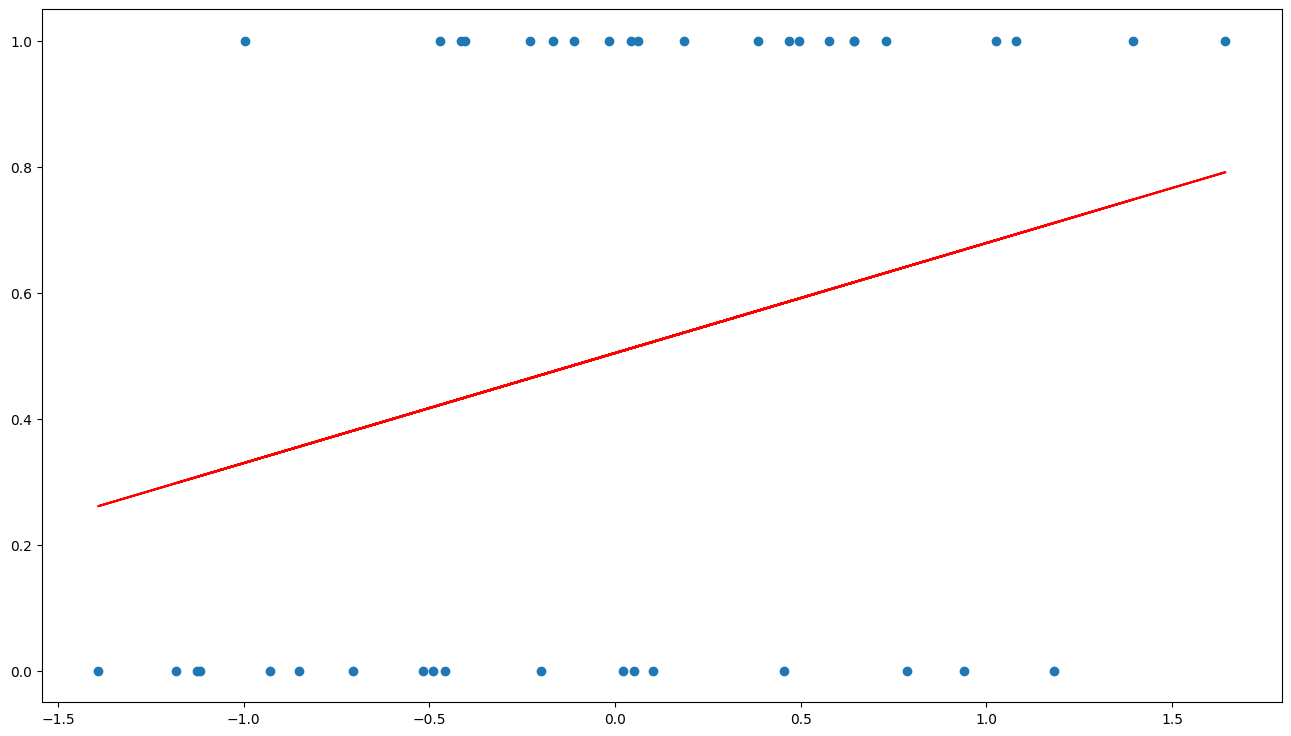

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,9))
plt.scatter(X_test_r,y_test_r)
plt.plot(X_test_r,y_pred_r,c='red')

In [47]:
lgst = LogisticRegression()

lgst.fit(X_train_c,y_train_c)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
y_test_c

95     0
15     1
30     1
158    0
128    1
115    1
69     0
170    0
174    0
45     1
66     1
182    1
165    0
78     0
186    0
177    0
56     0
152    1
82     1
68     0
124    0
16     0
148    1
93     1
65     1
60     1
84     1
67     0
125    0
132    1
9      1
18     1
55     1
75     0
150    0
104    1
135    1
137    0
164    1
76     1
Name: target, dtype: int64

In [53]:
probability = lgst.predict_proba(X_test_c)

In [69]:
prb = probability[:,1]

In [72]:
probability

array([[0.61921358, 0.38078642],
       [0.56916622, 0.43083378],
       [0.5252967 , 0.4747033 ],
       [0.57660032, 0.42339968],
       [0.42731152, 0.57268848],
       [0.46279673, 0.53720327],
       [0.65592538, 0.34407462],
       [0.48671246, 0.51328754],
       [0.49197213, 0.50802787],
       [0.26639265, 0.73360735],
       [0.3685659 , 0.6314341 ],
       [0.41313621, 0.58686379],
       [0.58245331, 0.41754669],
       [0.53105925, 0.46894075],
       [0.47735715, 0.52264285],
       [0.64328396, 0.35671604],
       [0.72619506, 0.27380494],
       [0.3126427 , 0.6873573 ],
       [0.23330192, 0.76669808],
       [0.6953973 , 0.3046027 ],
       [0.3347378 , 0.6652622 ],
       [0.29731183, 0.70268817],
       [0.48475135, 0.51524865],
       [0.51554643, 0.48445357],
       [0.40853573, 0.59146427],
       [0.38295476, 0.61704524],
       [0.666807  , 0.333193  ],
       [0.41538017, 0.58461983],
       [0.68573524, 0.31426476],
       [0.53628912, 0.46371088],
       [0.

In [70]:
(prb >= 0.5).astype('int32')

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0], dtype=int32)

In [75]:
lgst.predict(X_test_c)

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0])

In [87]:
(rg_prb >= 0.5).astype(int)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

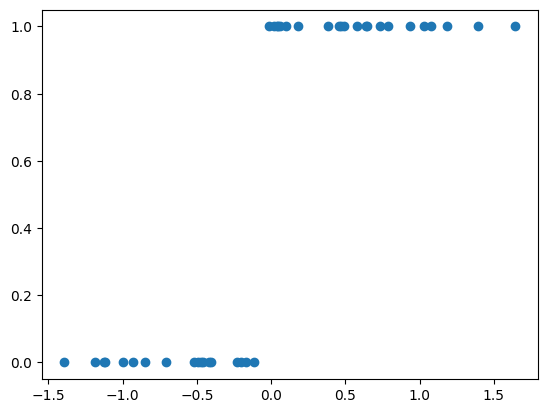

In [92]:
plt.scatter(X_test_c,lgst.predict(X_test_c))

In [88]:
X_train_r

,f1
79,1.326040
197,-0.626113
38,-1.060064
24,-0.994472
122,0.116538
...,...
106,-0.278931
14,0.192064
92,-0.644745
179,0.476185


In [89]:
X_train_c

,f1
79,1.326040
197,-0.626113
38,-1.060064
24,-0.994472
122,0.116538
...,...
106,-0.278931
14,0.192064
92,-0.644745
179,0.476185
